#### Tecnologie dei dati e del linguaggio
### Prof. Alfio Ferrara

# Introduzione alla vettorizzazione del testo
### Esempio con ricette di cucina

---

In questo notebook esploreremo come è possibile **rappresentare il testo in forma numerica**, passando da semplici osservazioni intuitive fino alla costruzione di vettori multidimensionali.

Questo è il punto di partenza per capire come funzionano i modelli di elaborazione del linguaggio naturale (**NLP**).

---
## 1. Il problema: confrontare testi

Iniziamo con un esempio concreto. Consideriamo tre ricette:

- **R1**: Taglia le cipolle e soffriggile in padella con olio.
- **R2**: Rosola l'aglio in padella con olio e aggiungi il pomodoro.
- **R3**: Mescola lo zucchero con la farina e cuoci in forno.

**Domanda:** quali ricette sono più simili tra loro?

La risposta intuitiva è che **R1 e R2** sono simili: entrambe parlano di cottura in padella con olio.  
**R3** è diversa: riguarda un dolce da cuocere in forno.

> 💡 **Idea chiave:** la similarità tra testi dipende dalle **parole** che contengono.

In [1]:
R1 = "Taglia le cipolle e soffriggile in padella con olio"
R2 = "Rosola l'aglio in padella con olio e aggiungi il pomodoro"
R3 = "Mescola lo zucchero con la farina e cuoci in forno"

ricette = {"R1": R1, "R2": R2, "R3": R3}

print("Le tre ricette:")
for nome, testo in ricette.items():
    print(f"  {nome}: {testo}")

Le tre ricette:
  R1: Taglia le cipolle e soffriggile in padella con olio
  R2: Rosola l'aglio in padella con olio e aggiungi il pomodoro
  R3: Mescola lo zucchero con la farina e cuoci in forno


### Associazione arbitraria di un numero alle parole

In [2]:
ricette = [R1, R2, R3]
vocabolario = set()
for r in ricette:
    for word in r.split():
        vocabolario.add(word.lower())

In [6]:
V = list(vocabolario)
#print(V)

ricette = {"R1": R1, "R2": R2, "R3": R3}
for t, r in ricette.items():
    i = [V.index(w.lower()) for w in r.split()]
    e = " ".join([str(x) for x in i])
    print(f"{t}: {e}")

R1: 17 19 11 12 5 20 0 3 16
R2: 15 13 20 0 3 16 12 10 8 18
R3: 7 4 6 3 9 2 12 14 20 1


---
## 2. Primo tentativo: rappresentare il testo con un numero

Una prima idea potrebbe essere rappresentare ogni ricetta con un **unico numero**: il numero di parole che contiene.

| Ricetta | Numero di parole |
|---------|------------------|
| R1      | 8                |
| R2      | 9                |
| R3      | 8                |

**Problema:** R1 e R3 avrebbero lo stesso valore (8), anche se parlano di cose completamente diverse!

> ❌ Un solo numero non è sufficiente a catturare il **contenuto** di un testo.

In [2]:
for nome, testo in ricette.items():
    n_parole = len(testo.split())
    print(f"  {nome}: {n_parole} parole")

print()
print("⚠️  R1 e R3 hanno lo stesso numero di parole, ma sono ricette molto diverse!")

  R1: 9 parole
  R2: 10 parole
  R3: 10 parole

⚠️  R1 e R3 hanno lo stesso numero di parole, ma sono ricette molto diverse!


---
## 3. Due dimensioni: rappresentazione geometrica

Scegliamo due parole significative e contiamo quante volte compaiono in ogni ricetta:

| Ricetta | padella | forno |
|---------|---------|-------|
| R1      | 1       | 0     |
| R2      | 1       | 0     |
| R3      | 0       | 1     |

Possiamo ora rappresentare ogni ricetta come un **punto su un piano cartesiano**:

- R1 = (1, 0)
- R2 = (1, 0)
- R3 = (0, 1)

**Interpretazione geometrica:**
- R1 e R2 coincidono nello stesso punto → sono molto simili
- R3 è in una posizione distante → è diversa

> 💡 La **similarità tra testi** può essere vista come **vicinanza tra punti** nello spazio.

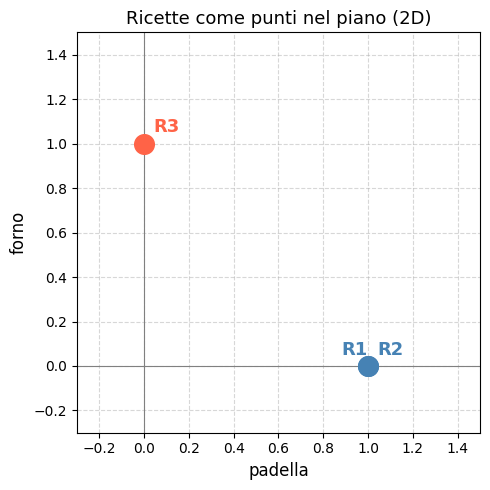

In [3]:
import matplotlib.pyplot as plt

vettori_2d = {"R1": (1, 0), "R2": (1, 0), "R3": (0, 1)}
colori = {"R1": "steelblue", "R2": "steelblue", "R3": "tomato"}
offset = {"R1": (-0.12, 0.05), "R2": (0.04, 0.05), "R3": (0.04, 0.05)}

fig, ax = plt.subplots(figsize=(5, 5))
for nome, (x, y) in vettori_2d.items():
    ax.scatter(x, y, s=200, color=colori[nome], zorder=5)
    ax.annotate(nome, (x, y),
                xytext=(x + offset[nome][0], y + offset[nome][1]),
                fontsize=13, fontweight="bold", color=colori[nome])

ax.set_xlim(-0.3, 1.5)
ax.set_ylim(-0.3, 1.5)
ax.set_xlabel("padella", fontsize=12)
ax.set_ylabel("forno", fontsize=12)
ax.set_title("Ricette come punti nel piano (2D)", fontsize=13)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
### 3.1 Distanza fra vettori come misurazione della similarità testuale

In [8]:
import numpy as np

def distanza_euclidea(v1, v2):
    v1, v2 = np.array(v1), np.array(v2)
    return np.sqrt(np.sum((v1 - v2) ** 2))

def distanza_coseno(v1, v2):
    v1, v2 = np.array(v1), np.array(v2)
    norma = np.linalg.norm(v1) * np.linalg.norm(v2)
    if norma == 0:
        return 0.0
    coseno = np.dot(v1, v2) / norma
    return 1 - coseno  # distanza = 1 - similarità


In [9]:
for i, (r, v) in enumerate(vettori_2d.items()):
    for k in list(vettori_2d.keys())[i+1:]:
        print(f"Distanza euclidea {r, k}: {distanza_euclidea(v, vettori_2d[k])}")
        print(f"Distanza coseno {r, k}: {distanza_coseno(v, vettori_2d[k])}")
        print("=========")

Distanza euclidea ('R1', 'R2'): 0.0
Distanza coseno ('R1', 'R2'): 0.0
Distanza euclidea ('R1', 'R3'): 1.4142135623730951
Distanza coseno ('R1', 'R3'): 1.0
Distanza euclidea ('R2', 'R3'): 1.4142135623730951
Distanza coseno ('R2', 'R3'): 1.0


---
## 4. Aumentare le dimensioni

Possiamo aggiungere altre parole al nostro **vocabolario** per ottenere rappresentazioni più ricche.

**Vocabolario:** `olio`, `padella`, `forno`, `zucchero`, `pomodoro`

Ogni ricetta diventa un **vettore a 5 dimensioni**:

| Ricetta | olio | padella | forno | zucchero | pomodoro |
|---------|------|---------|-------|----------|----------|
| R1      | 1    | 1       | 0     | 0        | 0        |
| R2      | 1    | 1       | 0     | 0        | 1        |
| R3      | 0    | 0       | 1     | 1        | 0        |

Con 5 dimensioni non possiamo più disegnare lo spazio su carta, ma **matematicamente funziona esattamente come prima**: ogni testo è ancora un punto nello spazio, solo in uno spazio più grande.

In [4]:
import numpy as np

vocabolario = ["olio", "padella", "forno", "zucchero", "pomodoro"]

def conta_parole(testo, vocabolario):
    """Crea un vettore contando le occorrenze di ogni parola del vocabolario nel testo."""
    testo_lower = testo.lower()
    return [testo_lower.count(parola) for parola in vocabolario]

vettori = {nome: conta_parole(testo, vocabolario) for nome, testo in ricette.items()}

print(f"Vocabolario: {vocabolario}")
print()
for nome, vett in vettori.items():
    print(f"  {nome} = {vett}")

Vocabolario: ['olio', 'padella', 'forno', 'zucchero', 'pomodoro']

  R1 = [1, 1, 0, 0, 0]
  R2 = [1, 1, 0, 0, 1]
  R3 = [0, 0, 1, 1, 0]


In [10]:
for i, (r, v) in enumerate(vettori.items()):
    for k in list(vettori.keys())[i+1:]:
        print(f"Distanza euclidea {r, k}: {distanza_euclidea(v, vettori[k])}")
        print(f"Distanza coseno {r, k}: {distanza_coseno(v, vettori[k])}")
        print("=========")

Distanza euclidea ('R1', 'R2'): 1.0
Distanza coseno ('R1', 'R2'): 0.18350341907227408
Distanza euclidea ('R1', 'R3'): 2.0
Distanza coseno ('R1', 'R3'): 1.0
Distanza euclidea ('R2', 'R3'): 2.23606797749979
Distanza coseno ('R2', 'R3'): 1.0


---
## 5. Il vettore del testo

Possiamo formalizzare questa idea in modo generale:

```
ricetta = (olio, padella, forno, zucchero, pomodoro)
```

- Ogni **dimensione** del vettore corrisponde a una parola del vocabolario.
- Il **valore** in quella dimensione è il numero di volte in cui quella parola compare nel testo.
- Il testo diventa così un **vettore numerico**.

Questa rappresentazione prende il nome di **Bag of Words (BoW)**: trattiamo il testo come un "sacchetto" di parole, ignorando l'ordine ma catturando presenza e frequenza di ciascun termine.

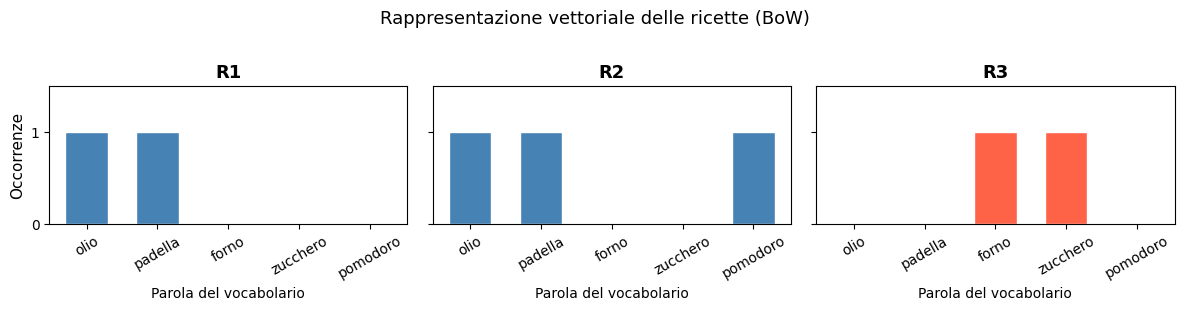

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
colori_barre = ["steelblue", "steelblue", "tomato"]

for ax, (nome, vett), colore in zip(axes, vettori.items(), colori_barre):
    ax.bar(vocabolario, vett, color=colore, edgecolor="white", width=0.6)
    ax.set_title(nome, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([0, 1])
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("Parola del vocabolario", fontsize=10)

axes[0].set_ylabel("Occorrenze", fontsize=11)
fig.suptitle("Rappresentazione vettoriale delle ricette (BoW)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Perché scegliere le parole come unità?

Potremmo usare unità diverse. Vediamo perché le parole sono la scelta migliore.

### Alternativa 1 – Caratteri
Useremmo le singole lettere come dimensioni (a, b, c, ...).

**Problema:** parole diverse possono avere sequenze di caratteri molto simili pur avendo significati completamente diversi.  
Esempio: `"forno"` e `"forma"` differiscono solo per l'ultima lettera.

### Alternativa 2 – Frasi intere
Ogni frase unica sarebbe una dimensione separata.

**Problema:** anche frasi quasi identiche verrebbero trattate come completamente diverse.  
Esempio: `"Rosola l'aglio in padella"` e `"Rosola lentamente l'aglio in padella"` sarebbero dimensioni distinte.

### ✅ Le parole: il giusto compromesso

| Proprietà                  | Caratteri | Parole | Frasi |
|----------------------------|-----------|--------|-------|
| Portano significato        | ❌        | ✅     | ✅    |
| Ricorrono in molti testi   | ✅        | ✅     | ❌    |
| Permettono confronti       | ❌        | ✅     | ❌    |

In [6]:
def vettore_caratteri(testo, chars):
    return [testo.lower().count(c) for c in chars]

chars = "aefmnor"
v_forno = vettore_caratteri("forno", chars)
v_forma = vettore_caratteri("forma", chars)

print("Rappresentazione a caratteri (sottoinsieme: a, e, f, m, n, o, r):")
print(f"  'forno' → {dict(zip(chars, v_forno))}")
print(f"  'forma' → {dict(zip(chars, v_forma))}")
print()
print("⚠️  I vettori sono quasi identici, ma 'forno' e 'forma' hanno significati molto diversi!")
print()
print("Rappresentazione a frasi:")
print("  'Rosola l'aglio in padella'            → [1, 0]")
print("  'Rosola lentamente l'aglio in padella' → [0, 1]")
print()
print("⚠️  Frasi quasi identiche risultano completamente diverse!")

Rappresentazione a caratteri (sottoinsieme: a, e, f, m, n, o, r):
  'forno' → {'a': 0, 'e': 0, 'f': 1, 'm': 0, 'n': 1, 'o': 2, 'r': 1}
  'forma' → {'a': 1, 'e': 0, 'f': 1, 'm': 1, 'n': 0, 'o': 1, 'r': 1}

⚠️  I vettori sono quasi identici, ma 'forno' e 'forma' hanno significati molto diversi!

Rappresentazione a frasi:
  'Rosola l'aglio in padella'            → [1, 0]
  'Rosola lentamente l'aglio in padella' → [0, 1]

⚠️  Frasi quasi identiche risultano completamente diverse!


---
## 7. Esempio finale: mettere tutto insieme

Consideriamo due nuove ricette e un vocabolario ridotto a 4 parole:

**Vocabolario:** `padella`, `forno`, `olio`, `zucchero`

- **A**: Scalda l'olio in padella e aggiungi le verdure.
- **B**: Mescola zucchero e farina e cuoci in forno.

I vettori risultanti:

```
A = (1, 0, 1, 0)   → cucina salata, cottura in padella
B = (0, 1, 0, 1)   → dolce, cottura in forno
```

---

> ## 🔑 Conclusione
>
> **Un modello NLP non legge il testo.**
>
> Lavora con **rappresentazioni numeriche** del testo sotto forma di **vettori**.
>
> Ogni parola del vocabolario è una dimensione. Ogni testo diventa un punto nello spazio vettoriale.  
> La similarità tra testi si misura come **vicinanza geometrica** tra questi punti.

In [7]:
import numpy as np

vocabolario_finale = ["padella", "forno", "olio", "zucchero"]

ricette_finali = {
    "A": "Scalda l'olio in padella e aggiungi le verdure",
    "B": "Mescola zucchero e farina e cuoci in forno",
}

vettori_finali = {
    nome: conta_parole(testo, vocabolario_finale)
    for nome, testo in ricette_finali.items()
}

print(f"Vocabolario: {vocabolario_finale}\n")
for nome, vett in vettori_finali.items():
    print(f"  Ricetta {nome}: '{ricette_finali[nome]}'")
    print(f"    → vettore: {vett}\n")

vA = np.array(vettori_finali["A"])
vB = np.array(vettori_finali["B"])
distanza = np.linalg.norm(vA - vB)

print(f"Distanza euclidea tra A e B: {distanza:.4f}")
print()
print("✅ I due vettori sono lontani nello spazio → le ricette sono diverse.")
print()
print("🔑 Un modello NLP non legge il testo.")
print("   Lavora con rappresentazioni numeriche sotto forma di vettori.")

Vocabolario: ['padella', 'forno', 'olio', 'zucchero']

  Ricetta A: 'Scalda l'olio in padella e aggiungi le verdure'
    → vettore: [1, 0, 1, 0]

  Ricetta B: 'Mescola zucchero e farina e cuoci in forno'
    → vettore: [0, 1, 0, 1]

Distanza euclidea tra A e B: 2.0000

✅ I due vettori sono lontani nello spazio → le ricette sono diverse.

🔑 Un modello NLP non legge il testo.
   Lavora con rappresentazioni numeriche sotto forma di vettori.
